## One Frame

------------
cluster= 0
amplitude= 1.1967165027939168 idx= (np.int64(6), np.int64(6), np.int64(154), np.int64(141))
selected elements: 92769
------------
cluster= 1
amplitude= 0.78952525926982 idx= (np.int64(14), np.int64(9), np.int64(115), np.int64(102))
selected elements: 670864
------------
cluster= 2
amplitude= 0.7746794990538869 idx= (np.int64(13), np.int64(10), np.int64(115), np.int64(102))
selected elements: 68593


C:\Users\domin\juwavelet\juwavelet\utils.py:67: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 22.79it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


cluster 0: amp=1.197, peak|rec|=1.945
cluster 1: amp=0.790, peak|rec|=2.145


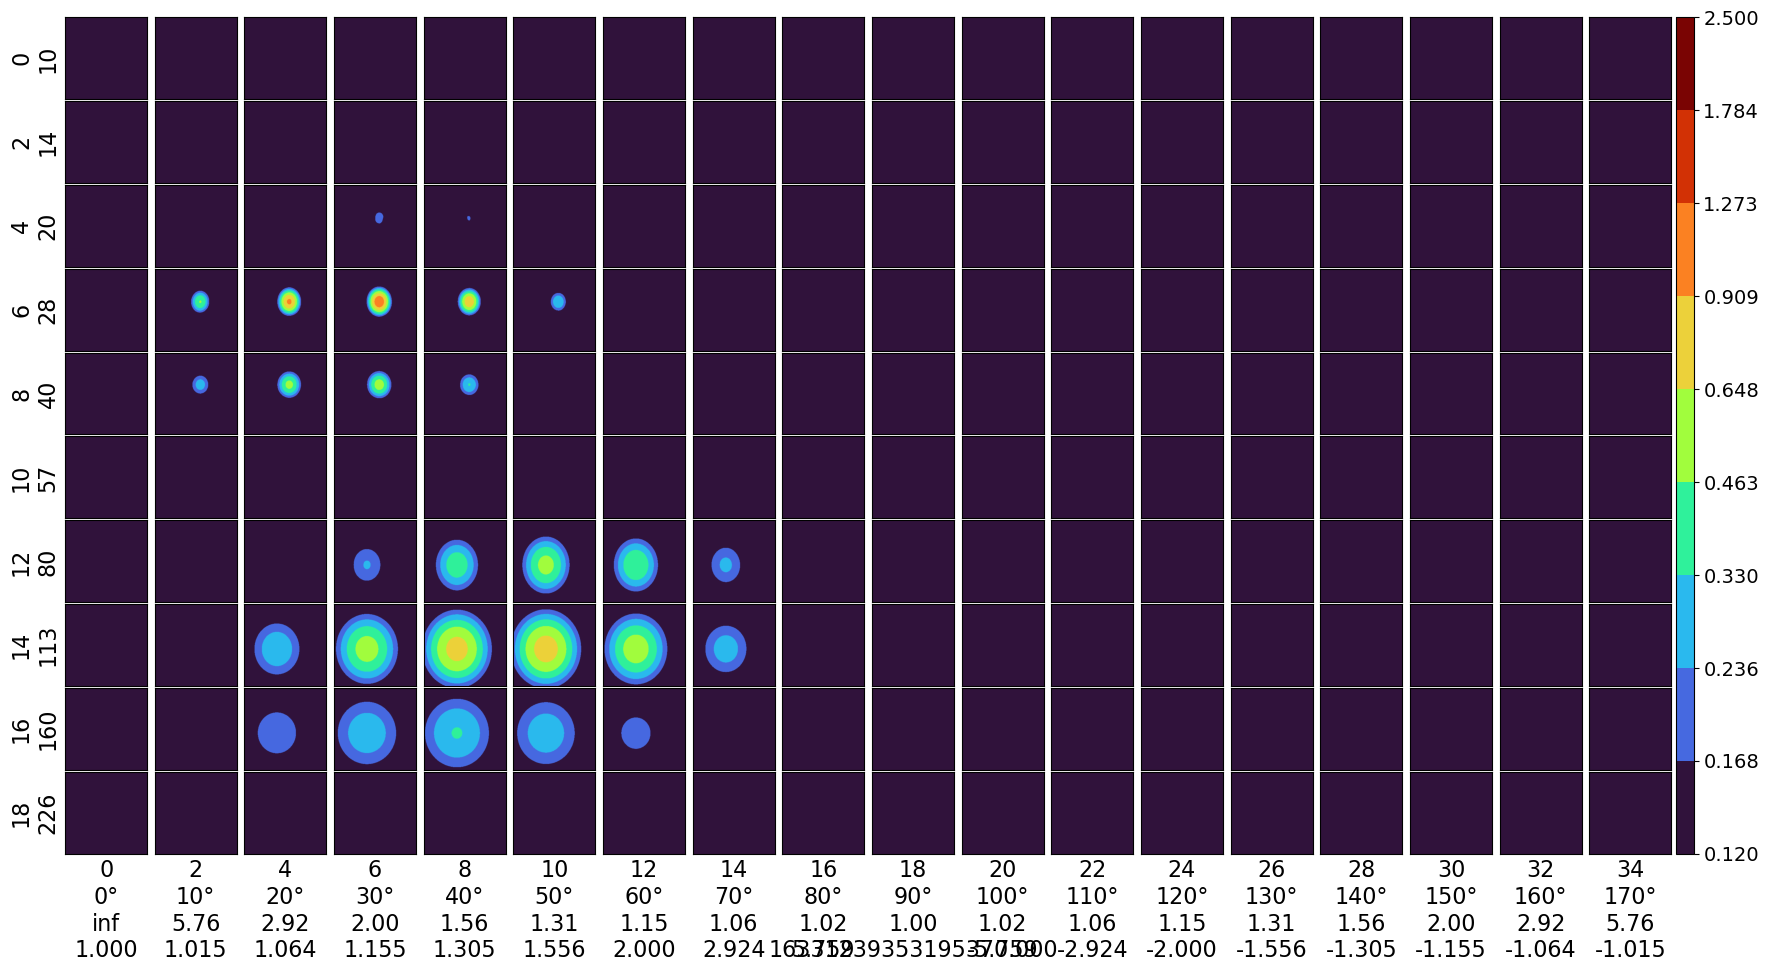

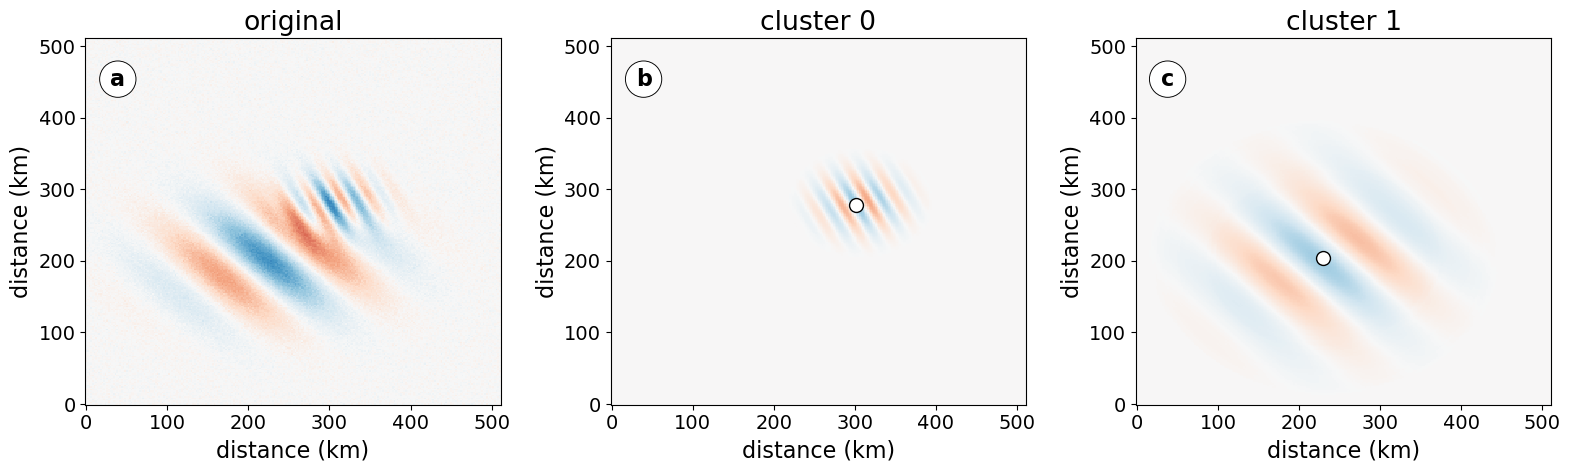

In [11]:
# example_decompose2d_synthetic_packets_only.py
# Synthetic 2D field with a couple of Gaussian wave packets (NO Kelvin wake),
# then run juwavelet 2D CWT and plot: original + 2 reconstructed clusters.

from __future__ import annotations
import math
import string
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Sequence, Tuple

# Inline plotting if you're in Jupyter
try:
    get_ipython  # type: ignore[name-defined]
    %matplotlib inline
except Exception:
    pass

from juwavelet import transform, utils

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})

# --------------------------
# Wave packets
# --------------------------
@dataclass
class WavePacket:
    """2D plane-wave packet with Gaussian envelope.
       A * exp(-((x-x0)^2/(2*sx^2) + (y-y0)^2/(2*sy^2))) * cos(kx*x + ky*y + phi)
       Provide (kx, ky) or (k, theta) in radians.
    """
    amplitude: float = 1.0
    kx: float | None = None
    ky: float | None = None
    k: float | None = None
    theta: float | None = None
    x0: float = 0.0
    y0: float = 0.0
    sx: float = 10.0
    sy: float = 10.0
    phi: float = 0.0

    def k_components(self) -> Tuple[float, float]:
        if self.kx is not None and self.ky is not None:
            return self.kx, self.ky
        if self.k is None or self.theta is None:
            raise ValueError("Provide either (kx, ky) or (k, theta) for WavePacket.")
        return self.k * math.cos(self.theta), self.k * math.sin(self.theta)

# --------------------------
# Grid + helpers
# --------------------------
def make_grid(nx: int, ny: int, dx: float, dy: float) -> Tuple[np.ndarray, np.ndarray]:
    x = np.arange(nx, dtype=float) * dx
    y = np.arange(ny, dtype=float) * dy
    X, Y = np.meshgrid(x, y)  # shapes (ny, nx)
    return X, Y

def packet_field(xs: np.ndarray, ys: np.ndarray, pkt: WavePacket) -> np.ndarray:
    kx, ky = pkt.k_components()
    gauss = np.exp(
        -(
            ((xs - pkt.x0) ** 2) / (2 * pkt.sx ** 2)
            + ((ys - pkt.y0) ** 2) / (2 * pkt.sy ** 2)
        )
    )
    phase = kx * xs + ky * ys + pkt.phi
    return pkt.amplitude * gauss * np.cos(phase)

# --------------------------
# Synthetic field (packets only)
# --------------------------
def generate_synthetic_field(
    nx: int = 256,
    ny: int = 256,
    dx: float = 2.0,
    dy: float = 2.0,
    packets: Sequence[WavePacket] | None = None,
    noise_sigma: float = 0.10,
    seed: int | None = 0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns xs, ys, total_field with shapes (ny, nx).
    """
    rng = np.random.default_rng(seed) if seed is not None else np.random.default_rng()
    xs, ys = make_grid(nx, ny, dx, dy)
    Lx = nx * dx
    Ly = ny * dy

    if packets is None:
        packets = [
            WavePacket(
                amplitude=3.0,
                k=2 * math.pi / 120.0,
                theta=math.radians(45),
                x0=0.45 * Lx,
                y0=0.40 * Ly,
                sx=86,
                sy=56,
                phi=0.0,
            ),
            WavePacket(
                amplitude=2.5,
                k=2 * math.pi / 32.0,
                theta=math.radians(28),
                x0=0.60 * Lx,
                y0=0.55 * Ly,
                sx=38,
                sy=28,
                phi=0.6,
            ),
        ]

    field = np.zeros_like(xs)
    for pkt in packets:
        field += packet_field(xs, ys, pkt)

    if noise_sigma > 0:
        field = field + rng.normal(0.0, noise_sigma, size=field.shape)

    return xs, ys, field

# --------------------------
# Pipeline
# --------------------------
def run_pipeline():
    # Build synthetic field (NO Kelvin wake)
    xs2d, ys2d, wave = generate_synthetic_field(
        nx=256, ny=256, dx=2.0, dy=2.0, seed=0
    )

    x1d = xs2d[0, :].copy()
    y1d = ys2d[:, 0].copy()
    x1d -= x1d[0]
    dx = np.diff(x1d).mean()
    dy = np.diff(y1d).mean()

    # juwavelet expects (nx, ny), so transpose
    wave_xy = wave.T

    cwt = transform.decompose2d(
        wave_xy, dx=dx, dy=dy, s0=10, dj=0.25, js=20, jt=36, aspect=1, mode = 'stockwell'
    )

    # Identify clusters (waves)
    amps, idxs, iwave = utils.identify_cluster2d(cwt, min_amp=.5, thr=0.25)

    decomposition = cwt["decomposition"]
    orig_decomp = decomposition.copy()

    # Overview CWT plot (optional but nice)
    cmap = matplotlib.cm.turbo
    norm = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.12), np.log(2.5), 10)), cmap.N
    )
    fig1, _ = utils.plot_decomposition2d(cwt, redux_s=2, redux_t=2, cmap=cmap, norm=norm)

    # Choose two clusters to plot (strongest two by amps, if available)
    if isinstance(amps, np.ndarray) and amps.size >= 2:
        pick = np.argsort(amps)[::-1][:2].tolist()
    else:
        pick = [0, 1]

    # Plot: original + 2 reconstructed clusters
    fig2, axs = plt.subplots(1, 3, figsize=(16, 5))
    opts = {"cmap": "RdBu_r", "vmin": -5, "vmax": 5, "rasterized": True}

    axs[0].set_title("original")
    axs[0].pcolormesh(x1d, y1d, wave, shading="auto", **opts)

    for j, cl in enumerate(pick, start=1):
        decomposition[:] = orig_decomp
        decomposition[iwave != cl] = 0
        rec = transform.reconstruct2d(cwt)  # (nx, ny)

        axs[j].set_title(f"cluster {cl}")
        axs[j].pcolormesh(x1d, y1d, rec.T, shading="auto", **opts)

        # mark the cluster's peak location (in the reconstructed map)
        A = np.abs(rec.T)  # (ny, nx) in plotting orientation
        iy, ix = np.unravel_index(np.argmax(A), A.shape)
        axs[j].plot(x1d[ix], y1d[iy], "o", color="w", mec="k", ms=10)

        # print a tiny summary
        try:
            print(f"cluster {cl}: amp={amps[cl]:.3f}, peak|rec|={A[iy, ix]:.3f}")
        except Exception:
            print(f"cluster {cl}: peak|rec|={A[iy, ix]:.3f}")

    for ax in axs:
        ax.set_xlabel("distance (km)")
        ax.set_ylabel("distance (km)")

    # letter tags
    letterbox = {"boxstyle": "circle", "lw": 0.67, "facecolor": "white", "edgecolor": "black"}
    for ax, letter in zip(axs, string.ascii_lowercase):
        ax.text(0.06, 0.92, letter, transform=ax.transAxes,
                bbox=letterbox, va="top", ha="left", weight="bold")

    fig2.tight_layout()
    plt.show(fig1)
    plt.show(fig2)

# --------------------------
# Run
# --------------------------
run_pipeline()

## Multiple Frames

In [15]:
# %%
# Animation with 3 panels:
#   (1) Original synthetic field (black/white)
#   (2) Reconstructed strongest cluster
#   (3) Reconstructed second-strongest cluster
#
# Motion:
#   - Big wave:   1/12 wavelength per frame
#   - Small wave: 1/24 wavelength per frame   (UPDATED)
# Total frames: 11
#
# Interval: doubled (was 300 ms -> now 600 ms)  (UPDATED)
# Saves animation to disk  (UPDATED)

from __future__ import annotations
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from juwavelet import transform, utils

# --------------------------
# Grid + timing
# --------------------------
NX, NY = 256, 256
DX, DY = 2.0, 2.0  # km
N_FRAMES = 11
INTERVAL_MS = 600  # doubled

x = np.arange(NX) * DX
y = np.arange(NY) * DY
X, Y = np.meshgrid(x, y)

# --------------------------
# Packet definitions
# --------------------------
Lx = NX * DX
Ly = NY * DY

big = dict(
    A=3.0,
    lam=120.0,
    theta=math.radians(45),
    x0=0.45 * Lx,
    y0=0.40 * Ly,
    sx=86.0,
    sy=56.0,
    phi0=0.0,
    dphi=2 * math.pi / 12,  # 1/12 λ per frame
)

small = dict(
    A=2.5,
    lam=32.0,
    theta=math.radians(28),
    x0=0.60 * Lx,
    y0=0.55 * Ly,
    sx=38.0,
    sy=28.0,
    phi0=0.6,
    dphi=2 * math.pi / 24,  # 1/24 λ per frame  (UPDATED)
)

# Sign convention:
# Negative means pattern moves along the wave direction
SIGN = -1.0

def packet_field(pkt, frame):
    k = 2 * math.pi / pkt["lam"]
    kx = k * math.cos(pkt["theta"])
    ky = k * math.sin(pkt["theta"])

    env = np.exp(
        -(((X - pkt["x0"]) ** 2) / (2 * pkt["sx"] ** 2)
          + ((Y - pkt["y0"]) ** 2) / (2 * pkt["sy"] ** 2))
    )

    phase = kx * X + ky * Y + pkt["phi0"] + SIGN * frame * pkt["dphi"]
    return pkt["A"] * env * np.cos(phase)

def synthetic_frame(i):
    return packet_field(big, i) + packet_field(small, i)

# --------------------------
# Figure setup
# --------------------------
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

for ax in axs:
    ax.set_xlabel("distance (km)")
    ax.set_ylabel("distance (km)")

axs[0].set_title("original")
axs[1].set_title("cluster 1")
axs[2].set_title("cluster 2")

# Original: black/white (UPDATED)
im0 = axs[0].imshow(
    np.zeros((NY, NX)),
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap="gray",
    vmin=-5,
    vmax=5,
    interpolation="nearest",
)

# Clusters: red/blue
im1 = axs[1].imshow(
    np.zeros((NY, NX)),
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap="RdBu_r",
    vmin=-5,
    vmax=5,
    interpolation="nearest",
)
im2 = axs[2].imshow(
    np.zeros((NY, NX)),
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap="RdBu_r",
    vmin=-5,
    vmax=5,
    interpolation="nearest",
)

plt.tight_layout()

# --------------------------
# Animation update
# --------------------------
def update(frame):
    # --- build field ---
    field = synthetic_frame(frame)

    # juwavelet expects (nx, ny)
    field_xy = field.T

    # --- CWT ---
    cwt = transform.decompose2d(
        field_xy,
        dx=DX,
        dy=DY,
        s0=10,
        dj=0.25,
        js=20,
        jt=36,
        aspect=1,
        mode="stockwell",
    )

    amps, idxs, iwave = utils.identify_cluster2d(cwt, min_amp=0.5, thr=0.25)

    # pick two strongest clusters
    order = np.argsort(amps)[::-1]
    clusters = order[:2] if order.size >= 2 else order

    decomposition = cwt["decomposition"]
    orig = decomposition.copy()

    # --- original panel ---
    im0.set_data(field)
    axs[0].set_title(f"original (frame {frame})")

    # --- reconstructed clusters ---
    rec_fields = []
    for cl in clusters:
        decomposition[:] = orig
        decomposition[iwave != cl] = 0.0
        rec = transform.reconstruct2d(cwt)  # (nx, ny)
        rec_fields.append(rec.T)

    # Fill panels (if fewer than 2 clusters found, blank the rest)
    if len(rec_fields) >= 1:
        im1.set_data(rec_fields[0])
        axs[1].set_title(f"cluster {int(clusters[0])}")
    else:
        im1.set_data(np.zeros((NY, NX)))
        axs[1].set_title("cluster (none)")

    if len(rec_fields) >= 2:
        im2.set_data(rec_fields[1])
        axs[2].set_title(f"cluster {int(clusters[1])}")
    else:
        im2.set_data(np.zeros((NY, NX)))
        axs[2].set_title("cluster (none)")

    return (im0, im1, im2)

anim = FuncAnimation(fig, update, frames=N_FRAMES, interval=INTERVAL_MS, blit=False)

# --------------------------
# Save animation (UPDATED)
# --------------------------
# Try MP4 (ffmpeg). If ffmpeg isn't available, fall back to GIF.
mp4_path = "synthetic_packets_juwavelet_3panel.mp4"
gif_path = "synthetic_packets_juwavelet_3panel.gif"

saved_to = None
try:
    fps = 1000.0 / INTERVAL_MS
    anim.save(mp4_path, writer="ffmpeg", fps=fps, dpi=140)
    saved_to = mp4_path
except Exception as e_mp4:
    try:
        from matplotlib.animation import PillowWriter
        fps = 1000.0 / INTERVAL_MS
        anim.save(gif_path, writer=PillowWriter(fps=fps), dpi=120)
        saved_to = gif_path
    except Exception as e_gif:
        print("Could not save MP4 or GIF.")
        print("MP4 error:", e_mp4)
        print("GIF error:", e_gif)

plt.close(fig)

if saved_to is not None:
    print("Saved animation to:", saved_to)

# Display in notebook
HTML(anim.to_jshtml())


C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 1.1975834660473725 idx= (np.int64(6), np.int64(6), np.int64(154), np.int64(141))
selected elements: 92673
------------
cluster= 1
amplitude= 0.7905527454873967 idx= (np.int64(14), np.int64(9), np.int64(115), np.int64(102))
selected elements: 671246
------------
cluster= 2
amplitude= 0.7756090452090744 idx= (np.int64(13), np.int64(10), np.int64(115), np.int64(102))
selected elements: 68786
------------
cluster= 0
amplitude= 1.1975834660473725 idx= (np.int64(6), np.int64(6), np.int64(154), np.int64(141))
selected elements: 92673
------------
cluster= 1
amplitude= 0.7905527454873967 idx= (np.int64(14), np.int64(9), np.int64(115), np.int64(102))
selected elements: 671246
------------
cluster= 2
amplitude= 0.7756090452090744 idx= (np.int64(13), np.int64(10), np.int64(115), np.int64(102))
selected elements: 68786
------------
cluster= 0
amplitude= 1.197586956074668 idx= (np.int64(6), np.int64(6), np.int64(154), np.int64(141))
selected elements: 92673
------

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 1.1975834660473725 idx= (np.int64(6), np.int64(6), np.int64(154), np.int64(141))
selected elements: 92673
------------
cluster= 1
amplitude= 0.7905527454873967 idx= (np.int64(14), np.int64(9), np.int64(115), np.int64(102))
selected elements: 671246
------------
cluster= 2
amplitude= 0.7756090452090744 idx= (np.int64(13), np.int64(10), np.int64(115), np.int64(102))
selected elements: 68786
------------
cluster= 0
amplitude= 1.1975834660473725 idx= (np.int64(6), np.int64(6), np.int64(154), np.int64(141))
selected elements: 92673
------------
cluster= 1
amplitude= 0.7905527454873967 idx= (np.int64(14), np.int64(9), np.int64(115), np.int64(102))
selected elements: 671246
------------
cluster= 2
amplitude= 0.7756090452090744 idx= (np.int64(13), np.int64(10), np.int64(115), np.int64(102))
selected elements: 68786
------------
cluster= 0
amplitude= 1.197586956074668 idx= (np.int64(6), np.int64(6), np.int64(154), np.int64(141))
selected elements: 92673
------

In [23]:
# %%
# 4-panel animation WITHOUT normalization:
#   (1) Cluster 0 reconstructed (raw, median-centered) + marker at selected point
#   (2) Time-trace: cluster 0 rec_centered at selected point (progressively drawn)
#   (3) Cluster 1 reconstructed (raw, median-centered) + marker at selected point
#   (4) Time-trace: cluster 1 rec_centered at selected point (progressively drawn)

from __future__ import annotations
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from juwavelet import transform, utils

# --------------------------
# Match previous synthetic setup
# --------------------------
NX, NY = 256, 256
DX, DY = 2.0, 2.0  # km
N_FRAMES = 11
INTERVAL_MS = 600

x = np.arange(NX) * DX
y = np.arange(NY) * DY
X, Y = np.meshgrid(x, y)
Lx = NX * DX
Ly = NY * DY

# Selected points you requested
x0_c0, y0_c0 = 0.60 * Lx, 0.55 * Ly
x0_c1, y0_c1 = 0.45 * Lx, 0.40 * Ly

def xy_to_ij(xp, yp):
    ix = int(np.clip(np.round(xp / DX), 0, NX - 1))
    iy = int(np.clip(np.round(yp / DY), 0, NY - 1))
    return ix, iy

ix0, iy0 = xy_to_ij(x0_c0, y0_c0)
ix1, iy1 = xy_to_ij(x0_c1, y0_c1)

# Packets (same as before: big 1/12, small 1/24)
big = dict(A=3.0, lam=120.0, theta=math.radians(45), x0=0.45*Lx, y0=0.40*Ly, sx=86.0, sy=56.0, phi0=0.0, dphi=2*math.pi/12)
small = dict(A=2.5, lam=32.0,  theta=math.radians(28), x0=0.60*Lx, y0=0.55*Ly, sx=38.0, sy=28.0, phi0=0.6, dphi=2*math.pi/24)
SIGN = -1.0

def packet_field(pkt, frame):
    k = 2 * math.pi / pkt["lam"]
    kx = k * math.cos(pkt["theta"])
    ky = k * math.sin(pkt["theta"])
    env = np.exp(-(((X - pkt["x0"])**2)/(2*pkt["sx"]**2) + ((Y - pkt["y0"])**2)/(2*pkt["sy"]**2)))
    phase = kx*X + ky*Y + pkt["phi0"] + SIGN*frame*pkt["dphi"]
    return pkt["A"] * env * np.cos(phase)

def synthetic_frame(i):
    return packet_field(big, i) + packet_field(small, i)

# --------------------------
# Reconstruct two strongest clusters (raw)
# --------------------------
def two_strongest_clusters_raw(field: np.ndarray):
    """
    Returns per frame:
      rec0_masked, rec1_masked : (NY, NX) reconstructed cluster fields (median-centered),
                                with NaNs outside each cluster mask
    where "cluster 0/1" are the 1st/2nd strongest clusters by amps.
    """
    field_xy = field.T  # (NX, NY)

    cwt = transform.decompose2d(
        field_xy, dx=DX, dy=DY, s0=10, dj=0.25, js=20, jt=36, aspect=1, mode="stockwell"
    )
    amps, idxs, iwave = utils.identify_cluster2d(cwt, min_amp=0.5, thr=0.25)
    order = np.argsort(amps)[::-1]

    if order.size == 0:
        z = np.full((NY, NX), np.nan)
        return z, z

    if order.size == 1:
        order = np.array([order[0], order[0]])

    cl0, cl1 = int(order[0]), int(order[1])

    decomp = cwt["decomposition"]
    orig = decomp.copy()

    def make_one(cl_id: int):
        # reconstruct
        decomp[:] = orig
        decomp[iwave != cl_id] = 0.0
        rec = transform.reconstruct2d(cwt).T  # (NY, NX)

        # median-centered (like your scripts)
        rec_centered = rec - np.median(rec)

        # mask outside cluster support
        mask_xy = np.any(iwave == cl_id, axis=(0, 1))  # (NX, NY)
        mask_img = mask_xy.T                            # (NY, NX)
        rec_masked = np.where(mask_img, rec_centered, np.nan)
        return rec_masked

    return make_one(cl0), make_one(cl1)

# --------------------------
# Precompute frames (only 11)
# --------------------------
rec0_frames = []
rec1_frames = []
a0 = np.full(N_FRAMES, np.nan)
a1 = np.full(N_FRAMES, np.nan)

for i in range(N_FRAMES):
    f = synthetic_frame(i)
    r0, r1 = two_strongest_clusters_raw(f)

    rec0_frames.append(np.ma.masked_invalid(r0))
    rec1_frames.append(np.ma.masked_invalid(r1))

    v0 = r0[iy0, ix0]
    v1 = r1[iy1, ix1]
    a0[i] = float(v0) if np.isfinite(v0) else np.nan
    a1[i] = float(v1) if np.isfinite(v1) else np.nan

t = np.arange(N_FRAMES)

# Set symmetric color limits from all frames (robust-ish)
all_vals = np.hstack([np.ravel(np.asarray(filled.data)) for filled in rec0_frames + rec1_frames])
all_vals = all_vals[np.isfinite(all_vals)]
if all_vals.size == 0:
    V = 1.0
else:
    # use percentiles so one crazy pixel doesn't ruin the color scale
    p2, p98 = np.percentile(all_vals, [2, 98])
    V = max(abs(p2), abs(p98))
    if not np.isfinite(V) or V == 0:
        V = np.max(np.abs(all_vals)) if all_vals.size else 1.0
        if not np.isfinite(V) or V == 0:
            V = 1.0

# --------------------------
# Plot / animate
# --------------------------
fig, axs = plt.subplots(2, 2, figsize=(12.8, 9.0))
ax_c0, ax_t0 = axs[0, 0], axs[0, 1]
ax_c1, ax_t1 = axs[1, 0], axs[1, 1]

im_c0 = ax_c0.imshow(
    rec0_frames[0],
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap="RdBu_r",
    vmin=-V, vmax=V,
    interpolation="nearest",
)
im_c1 = ax_c1.imshow(
    rec1_frames[0],
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap="RdBu_r",
    vmin=-V, vmax=V,
    interpolation="nearest",
)

for ax in (ax_c0, ax_c1):
    ax.set_xlabel("distance (km)")
    ax.set_ylabel("distance (km)")

pt0, = ax_c0.plot([x0_c0], [y0_c0], "o", ms=9, mfc="none", mec="k", mew=2)
pt1, = ax_c1.plot([x0_c1], [y0_c1], "o", ms=9, mfc="none", mec="k", mew=2)

for ax, title in ((ax_t0, "cluster 0: rec_centered at selected point"),
                  (ax_t1, "cluster 1: rec_centered at selected point")):
    ax.set_title(title)
    ax.set_xlim(0, N_FRAMES - 1)
    ax.set_xlabel("frame")
    ax.set_ylabel("reconstructed amplitude (centered)")
    ax.grid(True, alpha=0.25)

# y-limits based on traces
trace_vals = np.hstack([a0[np.isfinite(a0)], a1[np.isfinite(a1)]])
if trace_vals.size:
    q2, q98 = np.percentile(trace_vals, [2, 98])
    pad = 0.15 * max(1e-9, (q98 - q2))
    ylo, yhi = q2 - pad, q98 + pad
else:
    ylo, yhi = -1, 1
ax_t0.set_ylim(ylo, yhi)
ax_t1.set_ylim(ylo, yhi)

line0, = ax_t0.plot([], [], "o-", lw=2, ms=5)
line1, = ax_t1.plot([], [], "o-", lw=2, ms=5)

plt.tight_layout()

def update(frame):
    im_c0.set_data(rec0_frames[frame])
    im_c1.set_data(rec1_frames[frame])

    line0.set_data(t[:frame+1], a0[:frame+1])
    line1.set_data(t[:frame+1], a1[:frame+1])

    ax_c0.set_title(f"cluster 0 rec_centered (frame {frame})")
    ax_c1.set_title(f"cluster 1 rec_centered (frame {frame})")

    return (im_c0, im_c1, line0, line1, pt0, pt1)

anim_raw = FuncAnimation(fig, update, frames=N_FRAMES, interval=INTERVAL_MS, blit=False)
plt.close(fig)
HTML(anim_raw.to_jshtml())


C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 1.1975834660473725 idx= (np.int64(6), np.int64(6), np.int64(154), np.int64(141))
selected elements: 92673
------------
cluster= 1
amplitude= 0.7905527454873967 idx= (np.int64(14), np.int64(9), np.int64(115), np.int64(102))
selected elements: 671246
------------
cluster= 2
amplitude= 0.7756090452090744 idx= (np.int64(13), np.int64(10), np.int64(115), np.int64(102))
selected elements: 68786
------------
cluster= 0
amplitude= 1.197586956074668 idx= (np.int64(6), np.int64(6), np.int64(154), np.int64(141))
selected elements: 92673
------------
cluster= 1
amplitude= 0.7905526991241741 idx= (np.int64(14), np.int64(9), np.int64(115), np.int64(102))
selected elements: 671246
------------
cluster= 2
amplitude= 0.7756095181156772 idx= (np.int64(13), np.int64(10), np.int64(115), np.int64(102))
selected elements: 68786
------------
cluster= 0
amplitude= 1.1975890057181993 idx= (np.int64(6), np.int64(6), np.int64(154), np.int64(141))
selected elements: 92675
------

In [25]:
from matplotlib.animation import FFMpegWriter

fps = 1000.0 / INTERVAL_MS  # matches the animation speed
writer = FFMpegWriter(fps=fps, bitrate=1800)

anim_raw.save(
    "clusters_raw_amplitude.mp4",
    writer=writer,
    dpi=150
)
